In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from google.colab import files
uploaded = files.upload()

Saving advanced_stock_trading_dataset.csv to advanced_stock_trading_dataset.csv


In [3]:
import pandas as pd
df = pd.read_csv('advanced_stock_trading_dataset.csv')

In [ ]:
df.shape

(50000, 14)

In [ ]:
df.head()

,Date,Symbol,Open,High,Low,Close,Volume,SMA_10,SMA_50,EMA_20,RSI,MACD,Volatility,Trend
0,2010-01-01,AAPL,100.545817,102.012011,98.811775,101.277635,3266229,NaN,NaN,101.277635,NaN,0.000000,NaN,Bearish
1,2010-01-02,AAPL,100.326396,100.780772,99.412582,100.311336,4197750,NaN,NaN,101.185606,NaN,-0.077084,NaN,Bearish
2,2010-01-03,AAPL,101.482034,102.293857,100.547682,100.341371,2079147,NaN,NaN,101.105203,NaN,-0.134202,NaN,Bearish
3,2010-01-04,AAPL,103.295584,103.219549,100.833188,101.834849,1814284,NaN,NaN,101.174693,NaN,-0.058286,NaN,Bearish
4,2010-01-05,AAPL,102.638438,103.131313,101.351603,102.123689,3968084,NaN,NaN,101.265073,NaN,0.024898,NaN,Bearish


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        50000 non-null  object 
 1   Symbol      50000 non-null  object 
 2   Open        50000 non-null  float64
 3   High        50000 non-null  float64
 4   Low         50000 non-null  float64
 5   Close       50000 non-null  float64
 6   Volume      50000 non-null  int64  
 7   SMA_10      49991 non-null  float64
 8   SMA_50      49951 non-null  float64
 9   EMA_20      50000 non-null  float64
 10  RSI         49986 non-null  float64
 11  MACD        50000 non-null  float64
 12  Volatility  49991 non-null  float64
 13  Trend       50000 non-null  object 
dtypes: float64(10), int64(1), object(3)
memory usage: 5.3+ MB


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


In [ ]:
df.isnull().sum()

,0
Date,0
Symbol,0
Open,0
High,0
Low,0
Close,0
Volume,0
SMA_10,9
SMA_50,49
EMA_20,0


In [ ]:
df.describe()

,Open,High,Low,Close,Volume,SMA_10,SMA_50,EMA_20,RSI,MACD,Volatility
count,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,49991.000000,49951.000000,50000.000000,49986.000000,50000.000000,49991.000000
mean,97.583112,98.583720,96.582739,97.580594,3.000866e+06,97.582066,97.590313,97.585241,50.022588,-0.003539,1.349305
std,63.849646,63.846346,63.845228,63.852837,1.156757e+06,63.843593,63.814040,63.810772,14.217501,1.150868,0.513406
min,-91.368134,-90.636748,-93.069097,-91.600102,1.000045e+06,-89.588474,-87.654770,-88.231266,1.424558,-4.138773,0.273541
25%,56.207580,57.153803,55.145132,56.131771,1.992545e+06,56.072242,55.965683,56.182110,40.226628,-0.769805,0.981904
50%,96.990668,97.963020,96.064115,97.025824,3.001085e+06,96.901999,96.942162,97.085024,49.912373,0.002035,1.252771
75%,144.268026,145.310195,143.263063,144.239148,4.010322e+06,144.403571,144.480031,144.519139,59.743241,0.748703,1.619819
max,228.419891,229.280087,228.019723,228.188701,4.999624e+06,226.525862,224.279549,225.809250,99.140742,4.695734,4.249720


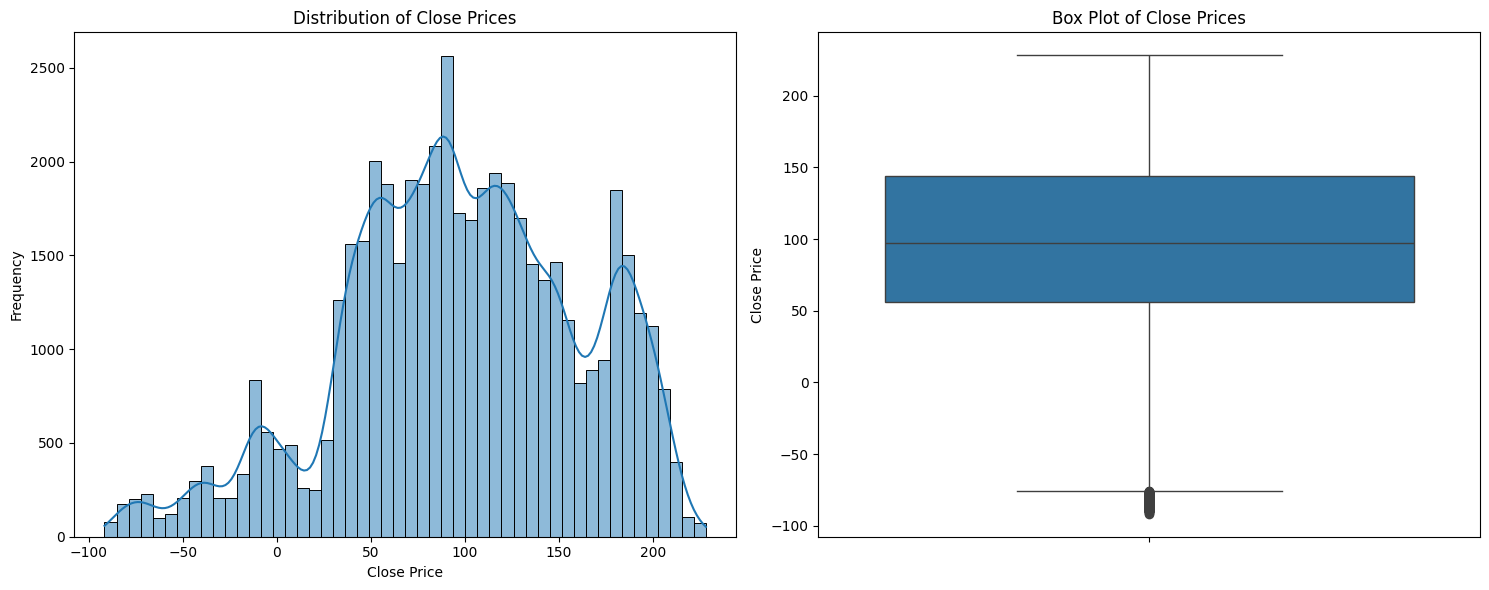

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Close'], kde=True, bins=50)
plt.title('Distribution of Close Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Close'])
plt.title('Box Plot of Close Prices')
plt.ylabel('Close Price')

plt.tight_layout()
plt.show()

In [ ]:
df_cleaned = df[df['Close'] > 0].copy()

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

Original dataset shape: (50000, 14)
Cleaned dataset shape: (45901, 14)


/tmp/ipykernel_1469/2134333386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Trend', data = df_cleaned, palette='viridis')


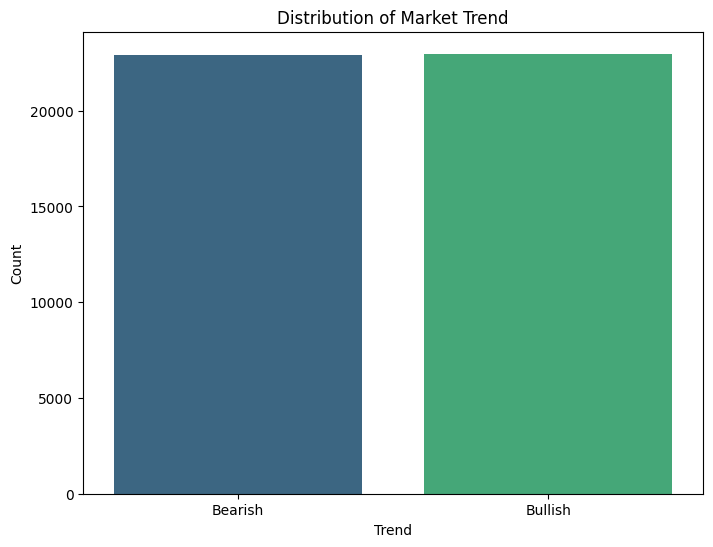

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Trend', data = df_cleaned, palette='viridis')
plt.title('Distribution of Market Trend')
plt.xlabel('Trend')
plt.ylabel('Count')
plt.show()

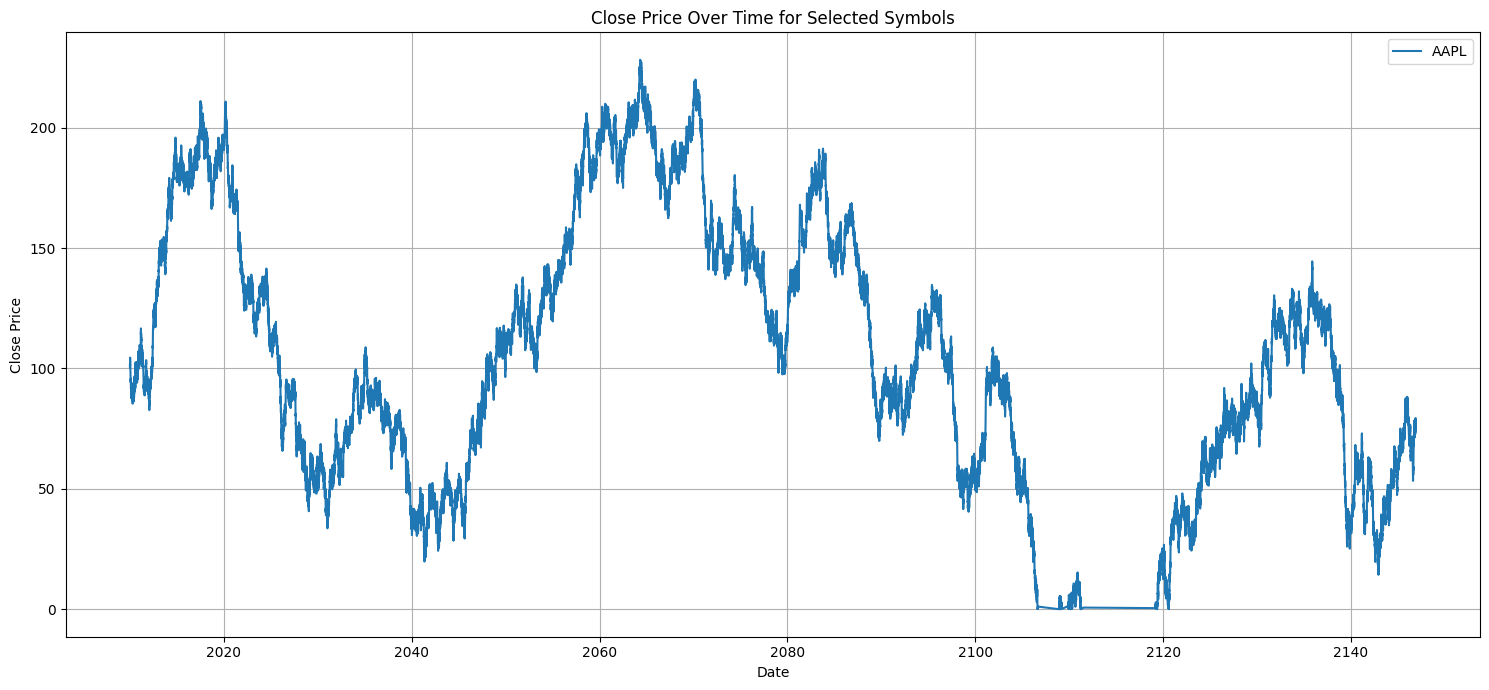

In [ ]:
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
df_cleaned = df_cleaned.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

symbols_to_plot = df_cleaned['Symbol'].unique()[:3]

plt.figure(figsize=(15, 7))
for symbol in symbols_to_plot:
    subset = df_cleaned[df_cleaned['Symbol'] == symbol]
    plt.plot(subset['Date'], subset['Close'], label=symbol)

plt.title('Close Price Over Time for Selected Symbols')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_cleaned['Daily_Return'] = df_cleaned['Close'].pct_change() * 100

df_cleaned['Close_Lag1'] = df_cleaned['Close'].shift(1)
df_cleaned['Volume_Lag1'] = df_cleaned['Volume'].shift(1)
df_cleaned['Daily_Return_Lag1'] = df_cleaned['Daily_Return'].shift(1)

df_cleaned['Open_Lag1'] = df_cleaned['Open'].shift(1)
df_cleaned['High_Lag1'] = df_cleaned['High'].shift(1)
df_cleaned['Low_Lag1'] = df_cleaned['Low'].shift(1)

df_cleaned['Day_of_Week'] = df_cleaned['Date'].dt.dayofweek
df_cleaned['Day_of_Month'] = df_cleaned['Date'].dt.day
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Year'] = df_cleaned['Date'].dt.year

df_fe = df_cleaned.dropna().copy()

display(df_fe.head())

,Date,Symbol,Open,High,Low,Close,Volume,SMA_10,SMA_50,EMA_20,...,Close_Lag1,Volume_Lag1,Day_of_Week,Day_of_Month,Month,Year,Daily_Return_Lag1,Open_Lag1,High_Lag1,Low_Lag1
49,2010-02-19,AAPL,89.857211,90.030565,88.079996,88.400899,1373455,90.659858,96.737088,92.123014,...,90.456775,1696724.0,4,19,2,2010,0.207777,91.351733,90.633292,90.328966
50,2010-02-20,AAPL,88.232608,90.059455,88.806810,87.721596,1042814,90.227565,96.465968,91.703832,...,88.400899,1373455.0,5,20,2,2010,-2.272771,89.857211,90.030565,88.079996
51,2010-02-21,AAPL,87.927032,89.623580,88.153446,88.514122,3136989,89.898638,96.230023,91.400050,...,87.721596,1042814.0,6,21,2,2010,-0.768434,88.232608,90.059455,88.806810
52,2010-02-22,AAPL,87.608700,89.986492,86.173111,87.992232,3368085,89.508561,95.983040,91.075496,...,88.514122,3136989.0,0,22,2,2010,0.903456,87.927032,89.623580,88.153446
53,2010-02-23,AAPL,88.255297,90.070722,88.085683,88.143540,2499011,89.126139,95.709214,90.796262,...,87.992232,3368085.0,1,23,2,2010,-0.589613,87.608700,89.986492,86.173111


In [ ]:
df_fe = pd.get_dummies(df_fe, columns=['Trend'], drop_first=True)
display(df_fe.head())

,Date,Symbol,Open,High,Low,Close,Volume,SMA_10,SMA_50,EMA_20,...,MACD,Volatility,Daily_Return,Close_Lag1,Volume_Lag1,Day_of_Week,Day_of_Month,Month,Year,Trend_Bullish
49,2010-02-19,AAPL,89.857211,90.030565,88.079996,88.400899,1373455,90.659858,96.737088,92.123014,...,-2.026221,1.233618,-2.272771,90.456775,1696724.0,4,19,2,2010,False
50,2010-02-20,AAPL,88.232608,90.059455,88.806810,87.721596,1042814,90.227565,96.465968,91.703832,...,-2.130653,1.435410,-0.768434,88.400899,1373455.0,5,20,2,2010,False
51,2010-02-21,AAPL,87.927032,89.623580,88.153446,88.514122,3136989,89.898638,96.230023,91.400050,...,-2.124971,1.410844,0.903456,87.721596,1042814.0,6,21,2,2010,False
52,2010-02-22,AAPL,87.608700,89.986492,86.173111,87.992232,3368085,89.508561,95.983040,91.075496,...,-2.137935,1.335400,-0.589613,88.514122,3136989.0,0,22,2,2010,False
53,2010-02-23,AAPL,88.255297,90.070722,88.085683,88.143540,2499011,89.126139,95.709214,90.796262,...,-2.111657,1.075113,0.171956,87.992232,3368085.0,1,23,2,2010,False


In [ ]:
from sklearn.model_selection import train_test_split

features_for_regression = ['Volume', 'RSI', 'MACD', 'Volatility', 'Volume_Lag1',
                           'Day_of_Week', 'Day_of_Month', 'Month', 'Year']
X = df_fe[features_for_regression]
y = df_fe['Close']

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (36681, 9)
X_test shape: (9171, 9)
y_train shape: (36681,)
y_test shape: (9171,)


In [ ]:
if 'df_cleaned' not in locals() and 'df_cleaned' not in globals():
    df_cleaned = df[df['Close'] > 0].copy()
    df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
    df_cleaned = df_cleaned.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    df_cleaned['Daily_Return'] = df_cleaned['Close'].pct_change() * 100
    df_cleaned['Close_Lag1'] = df_cleaned['Close'].shift(1)
    df_cleaned['Volume_Lag1'] = df_cleaned['Volume'].shift(1)
    df_cleaned['Day_of_Week'] = df_cleaned['Date'].dt.dayofweek
    df_cleaned['Day_of_Month'] = df_cleaned['Date'].dt.day
    df_cleaned['Month'] = df_cleaned['Date'].dt.month
    df_cleaned['Year'] = df_cleaned['Date'].dt.year

if 'df_fe' not in locals() and 'df_fe' not in globals():
    df_fe = df_cleaned.dropna().copy()
    df_fe = pd.get_dummies(df_fe, columns=['Trend'], drop_first=True)

X_clf = df_fe.drop(['Date', 'Symbol', 'Close', 'Trend_Bullish'], axis=1)
y_clf = df_fe['Trend_Bullish']

split_index_clf = int(len(X_clf) * 0.8)
X_train_clf, X_test_clf = X_clf.iloc[:split_index_clf], X_clf.iloc[split_index_clf:]
y_train_clf, y_test_clf = y_clf.iloc[:split_index_clf], y_clf.iloc[split_index_clf:]

print(f"X_train_clf shape: {X_train_clf.shape}")
print(f"X_test_clf shape: {X_test_clf.shape}")
print(f"y_train_clf shape: {y_train_clf.shape}")
print(f"y_test_clf shape: {y_test_clf.shape}")

X_train_clf shape: (36681, 17)
X_test_clf shape: (9171, 17)
y_train_clf shape: (36681,)
y_test_clf shape: (9171,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

log_reg_model.fit(X_train_clf, y_train_clf)

y_pred_clf = log_reg_model.predict(X_test_clf)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_clf))

Accuracy: 0.9549

Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.96      0.95      4384
        True       0.96      0.95      0.96      4787

    accuracy                           0.95      9171
   macro avg       0.95      0.96      0.95      9171
weighted avg       0.96      0.95      0.95      9171


Confusion Matrix:
[[4213  171]
 [ 243 4544]]


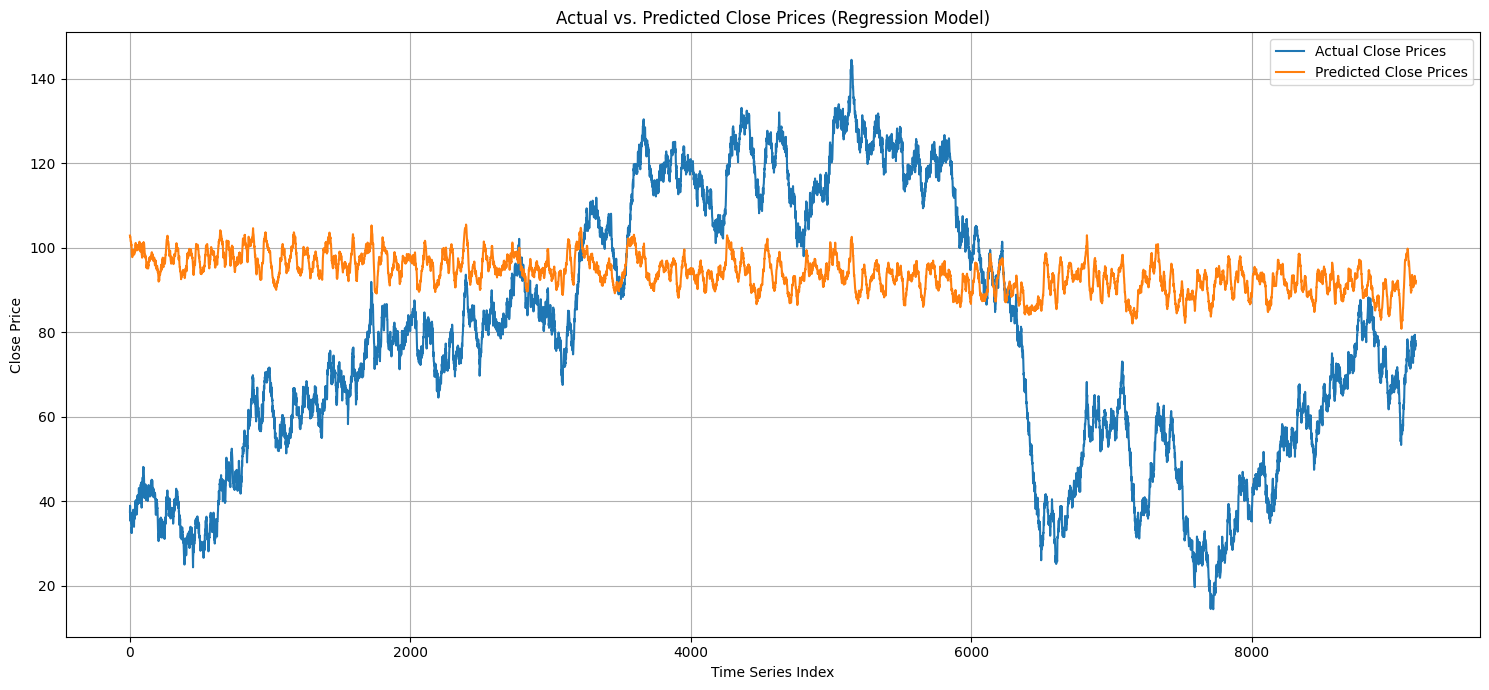

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(y_test.values, label='Actual Close Prices')
plt.plot(y_pred, label='Predicted Close Prices')
plt.title('Actual vs. Predicted Close Prices (Regression Model)')
plt.xlabel('Time Series Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) for the regression model: {mse:.2f}")

Mean Squared Error (MSE) for the regression model: 1213.06


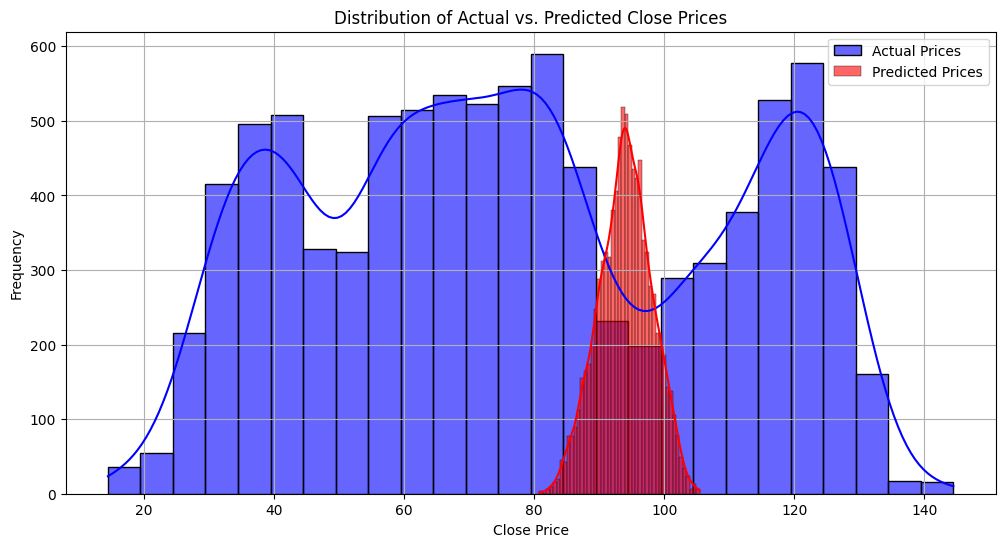

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(y_test, color='blue', label='Actual Prices', kde=True, alpha=0.6)
sns.histplot(y_pred, color='red', label='Predicted Prices', kde=True, alpha=0.6)
plt.title('Distribution of Actual vs. Predicted Close Prices')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

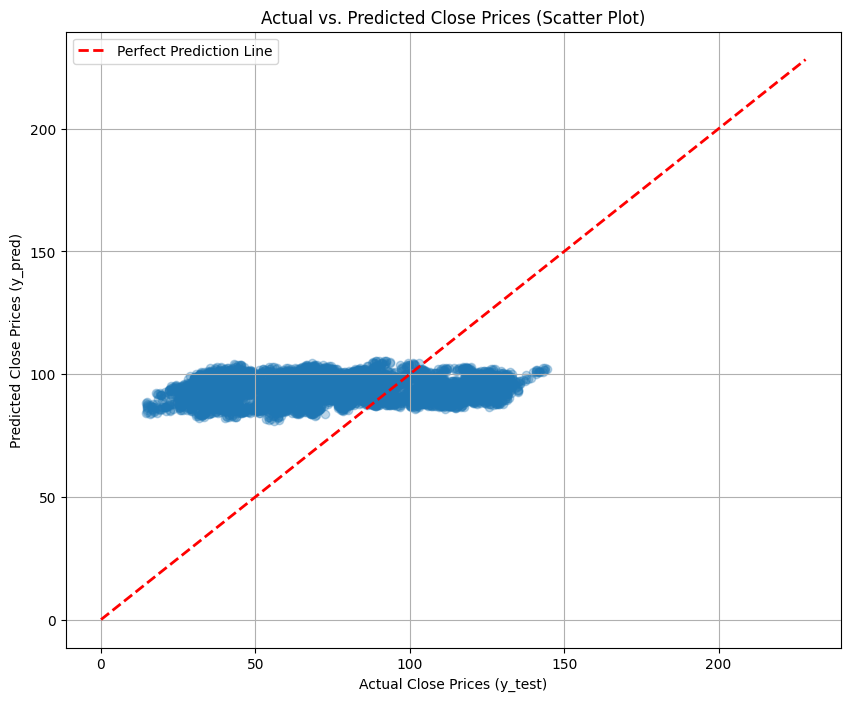

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction Line') # 45-degree line
plt.xlabel('Actual Close Prices (y_test)')
plt.ylabel('Predicted Close Prices (y_pred)')
plt.title('Actual vs. Predicted Close Prices (Scatter Plot)')
plt.legend()
plt.grid(True)
plt.show()

### Addressing Underfitting in the Regression Model

The current regression model is clearly underfitting, as evidenced by the high Mean Squared Error (MSE) and the scatter plot showing predicted values clustered in a narrow range, failing to capture the variance in actual prices.

To improve the model, we need to enrich our feature set with more sophisticated non-leaking indicators. These features aim to capture additional market dynamics and patterns that a simple linear model might miss. We will then use a more powerful model, such as a `RandomForestRegressor`, to leverage these features effectively.

In [5]:
# Ensure df_fe exists or recreate it if the kernel state was reset
if 'df_fe' not in locals() and 'df_fe' not in globals():
    if 'df_cleaned' not in locals() and 'df_cleaned' not in globals():
        df_cleaned = df[df['Close'] > 0].copy()
        df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
        df_cleaned = df_cleaned.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

        df_cleaned['Daily_Return'] = df_cleaned['Close'].pct_change() * 100
        df_cleaned['Close_Lag1'] = df_cleaned['Close'].shift(1)
        df_cleaned['Volume_Lag1'] = df_cleaned['Volume'].shift(1)
        df_cleaned['Daily_Return_Lag1'] = df_cleaned['Daily_Return'].shift(1)

        df_cleaned['Open_Lag1'] = df_cleaned['Open'].shift(1)
        df_cleaned['High_Lag1'] = df_cleaned['High'].shift(1)
        df_cleaned['Low_Lag1'] = df_cleaned['Low'].shift(1)

        df_cleaned['Day_of_Week'] = df_cleaned['Date'].dt.dayofweek
        df_cleaned['Day_of_Month'] = df_cleaned['Date'].dt.day
        df_cleaned['Month'] = df_cleaned['Date'].dt.month
        df_cleaned['Year'] = df_cleaned['Date'].dt.year

    df_fe = df_cleaned.dropna().copy()
    df_fe = pd.get_dummies(df_fe, columns=['Trend'], drop_first=True)

# Generate new non-leaking features
# Price_Range: Difference between High and Low prices, indicating intra-day volatility.
df_fe['Price_Range'] = df_fe['High_Lag1'] - df_fe['Low_Lag1'] # Using lagged High/Low

# Open_Close_Diff: Difference between Open and Close prices, indicating daily sentiment.
df_fe['Open_Close_Diff'] = df_fe['Open_Lag1'] - df_fe['Close_Lag1'] # Using lagged Open/Close

# Volume_Change: Percentage change in Volume from the previous day, capturing volume momentum.
df_fe['Volume_Change'] = df_fe.groupby('Symbol')['Volume'].pct_change() * 100

# RSI_Volume_Interaction: An interaction term between RSI and Volume_Change, to see if high volume
# in overbought/oversold conditions has a distinct effect.
df_fe['RSI_Volume_Interaction'] = df_fe['RSI'] * df_fe['Volume_Change']

# MACD_Volatility_Interaction: An interaction term between MACD and Volatility.
df_fe['MACD_Volatility_Interaction'] = df_fe['MACD'] * df_fe['Volatility']

# Volatility_Daily_Return_Interaction: An interaction term between Volatility and Daily_Return_Lag1.
df_fe['Volatility_Daily_Return_Interaction'] = df_fe['Volatility'] * df_fe['Daily_Return_Lag1']

# Drop NaN values that might result from new feature creation
df_fe.dropna(inplace=True)

print(f"Shape of df_fe after adding new features: {df_fe.shape}")
display(df_fe.head())

Shape of df_fe after adding new features: (45851, 31)


,Date,Symbol,Open,High,Low,Close,Volume,SMA_10,SMA_50,EMA_20,...,Day_of_Month,Month,Year,Trend_Bullish,Price_Range,Open_Close_Diff,Volume_Change,RSI_Volume_Interaction,MACD_Volatility_Interaction,Volatility_Daily_Return_Interaction
50,2010-02-20,AAPL,88.232608,90.059455,88.806810,87.721596,1042814,90.227565,96.465968,91.703832,...,20,2,2010,False,1.950569,1.456312,-24.073668,-358.846691,-3.058360,-3.262357
51,2010-02-21,AAPL,87.927032,89.623580,88.153446,88.514122,3136989,89.898638,96.230023,91.400050,...,21,2,2010,False,1.252645,0.511012,200.819609,5300.068197,-2.998002,-1.084141
52,2010-02-22,AAPL,87.608700,89.986492,86.173111,87.992232,3368085,89.508561,95.983040,91.075496,...,22,2,2010,False,1.470134,-0.587090,7.366809,204.309939,-2.854997,1.206474
53,2010-02-23,AAPL,88.255297,90.070722,88.085683,88.143540,2499011,89.126139,95.709214,90.796262,...,23,2,2010,False,3.813381,-0.383531,-25.803209,-710.040103,-2.270269,-0.633900
54,2010-02-24,AAPL,89.243430,90.166998,89.002183,89.966855,1687892,89.087585,95.466078,90.717271,...,24,2,2010,False,1.985039,0.111757,-32.457600,-1274.329146,-1.983649,0.177513


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

features_for_rf_regression = ['Volume', 'RSI', 'MACD', 'Volatility', 'Volume_Lag1',
                                'Daily_Return_Lag1', 'Open_Lag1', 'High_Lag1', 'Low_Lag1',
                                'Day_of_Week', 'Day_of_Month', 'Month', 'Year',
                                'Trend_Bullish',
                                'Price_Range', 'Open_Close_Diff', 'Volume_Change',
                                'RSI_Volume_Interaction', 'MACD_Volatility_Interaction',
                                'Volatility_Daily_Return_Interaction']

existing_features_for_rf = [f for f in features_for_rf_regression if f in df_fe.columns]

X = df_fe[existing_features_for_rf]
y = df_fe['Close']

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"X_train shape with enhanced features: {X_train.shape}")
print(f"X_test shape with enhanced features: {X_test.shape}")

rf_regressor_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor_model.fit(X_train, y_train)

y_pred_rf = rf_regressor_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nMean Squared Error (MSE) with RandomForestRegressor: {mse_rf:.2f}")
print(f"R-squared (R2) with RandomForestRegressor: {r2_rf:.2f}")

X_train shape with enhanced features: (36680, 20)
X_test shape with enhanced features: (9171, 20)

Mean Squared Error (MSE) with RandomForestRegressor: 1.33
R-squared (R2) with RandomForestRegressor: 1.00


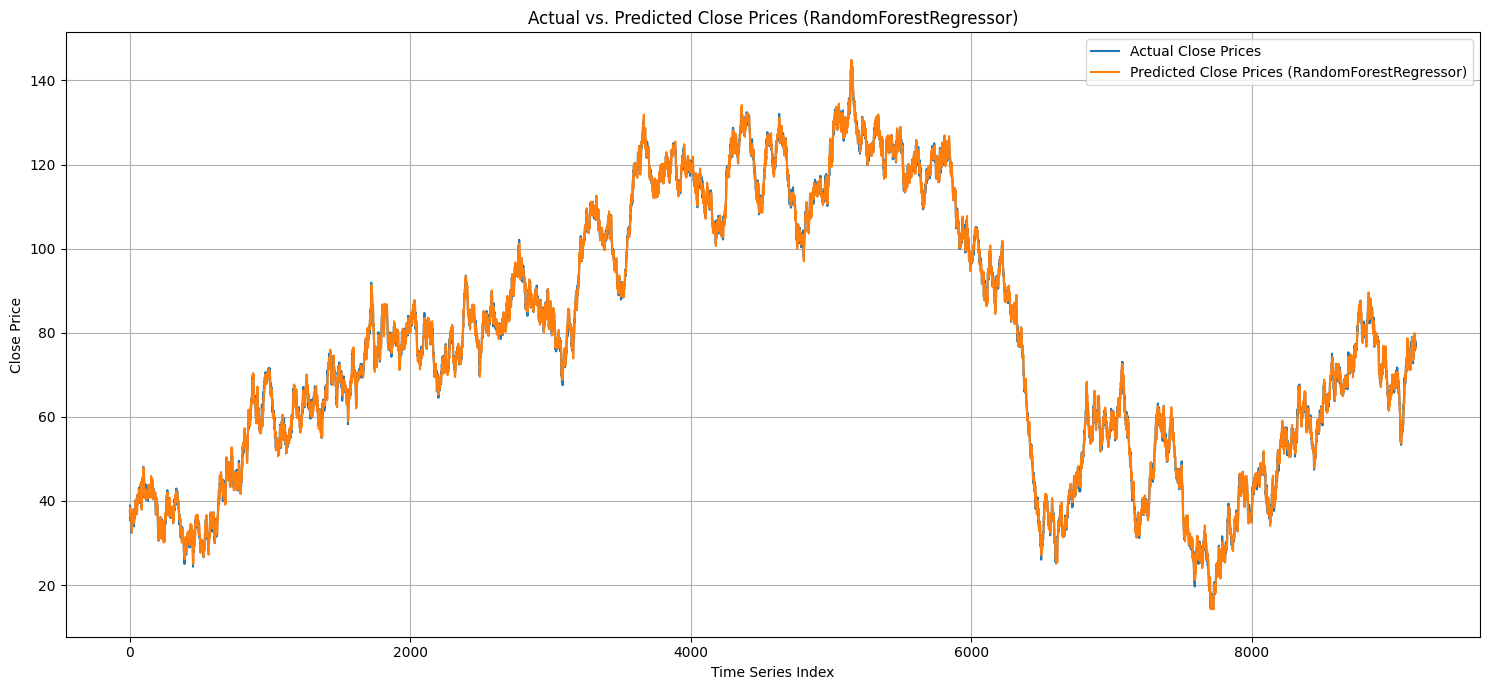

In [7]:
plt.figure(figsize=(15, 7))
plt.plot(y_test.values, label='Actual Close Prices')
plt.plot(y_pred_rf, label='Predicted Close Prices (RandomForestRegressor)')
plt.title('Actual vs. Predicted Close Prices (RandomForestRegressor)')
plt.xlabel('Time Series Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

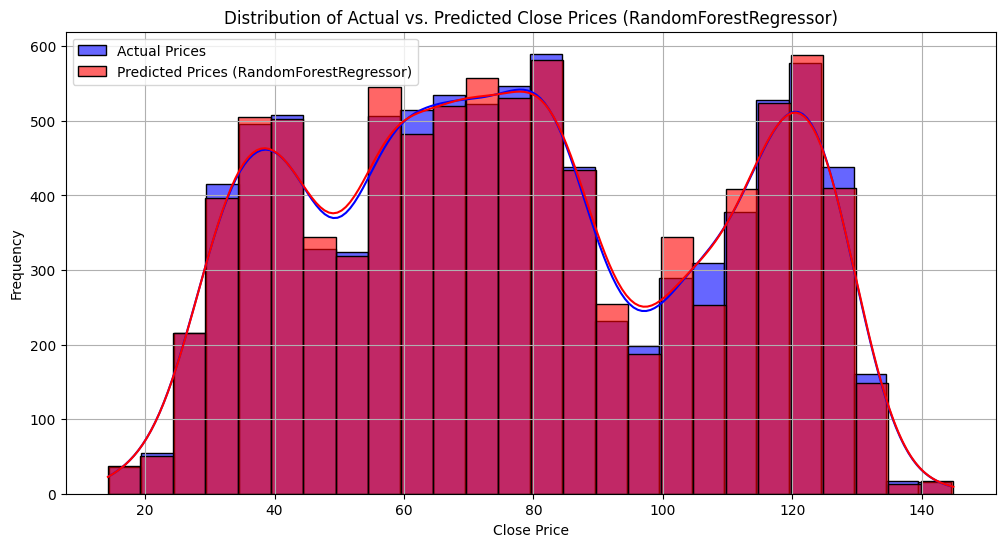

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(y_test, color='blue', label='Actual Prices', kde=True, alpha=0.6)
sns.histplot(y_pred_rf, color='red', label='Predicted Prices (RandomForestRegressor)', kde=True, alpha=0.6)
plt.title('Distribution of Actual vs. Predicted Close Prices (RandomForestRegressor)')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

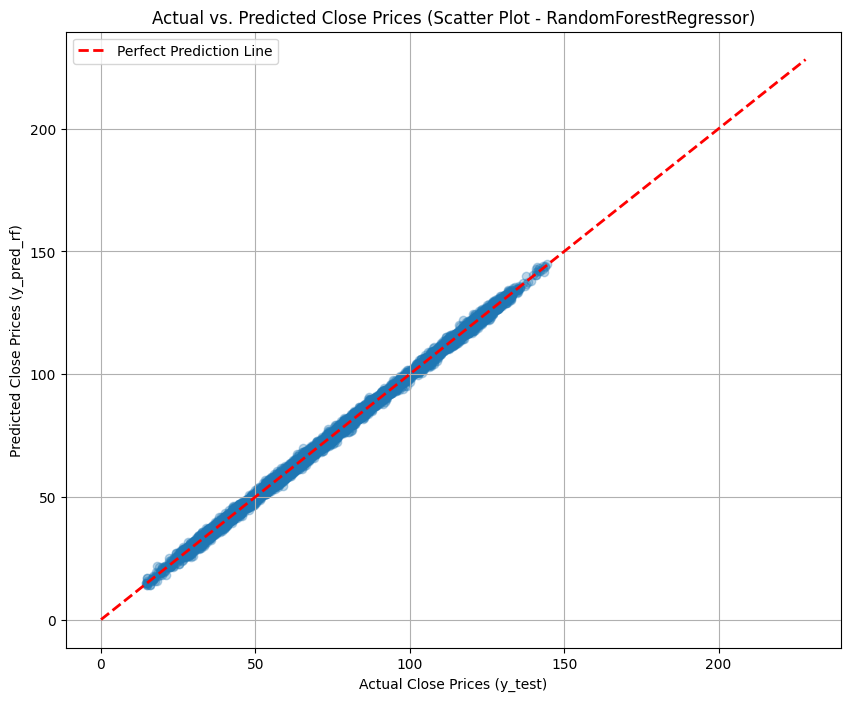

In [9]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction Line') # 45-degree line
plt.xlabel('Actual Close Prices (y_test)')
plt.ylabel('Predicted Close Prices (y_pred_rf)')
plt.title('Actual vs. Predicted Close Prices (Scatter Plot - RandomForestRegressor)')
plt.legend()
plt.grid(True)
plt.show()